In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from textblob import TextBlob
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("twitter_training.csv", header=None)
df.columns = ["ID", "Topic", "Sentiment", "Text"]

df.head()

,ID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
# Rename columns if needed
df.columns = ['id', 'topic', 'sentiment', 'text']

# Remove null values
df.dropna(inplace=True)

# Convert text to string
df['text'] = df['text'].astype(str)

In [4]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['predicted_sentiment'] = df['text'].apply(get_sentiment)

In [5]:
sentiment_counts = df['predicted_sentiment'].value_counts()

print(sentiment_counts)

predicted_sentiment
Positive    34074
Negative    21358
Neutral     18564
Name: count, dtype: int64


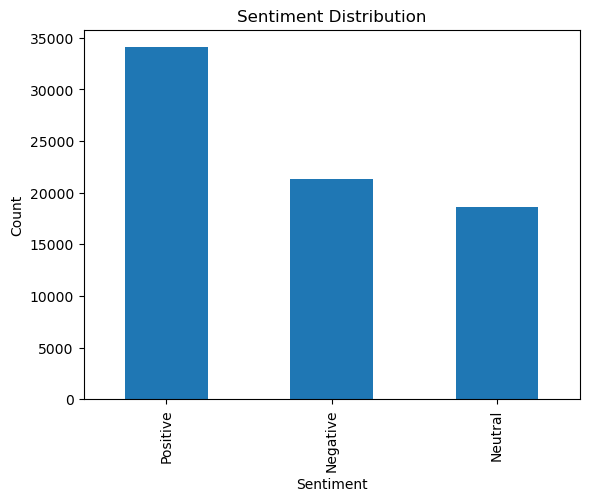

In [6]:
sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

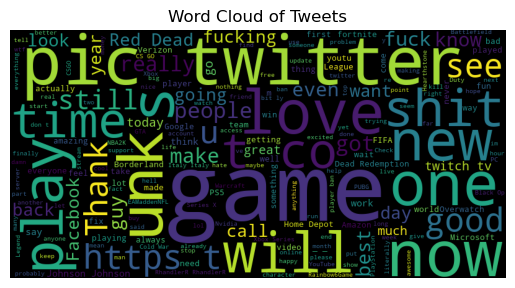

In [7]:
text_data = " ".join(df['text'])

wordcloud = WordCloud(width=800, height=400).generate(text_data)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Tweets")
plt.show()